# Notebook 03 — BERT Fine-Tuning
**Project:** TruthLens — Multilingual Fake News Detection  
**Goal:** Fine-tune DistilBERT on fake news data and compare against classical ML models

**Why BERT beats TF-IDF:**
- TF-IDF treats every word independently — no context
- BERT reads entire sentences and understands meaning
- Example: 'Bank of the river' vs 'Bank of America' — TF-IDF sees same word, BERT understands different meaning

---

## 1. Install & Import Libraries

In [24]:
# Install required libraries (run once)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'transformers', 'torch', 'datasets', 'accelerate', '-q'])

print('Installation complete ✓')

Installation complete ✓


In [25]:
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('dark_background')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
    confusion_matrix
)
import seaborn as sns

# Paths
MODELS_DIR   = '../models/'
DATASETS_DIR = '../datasets/'
BERT_DIR     = '../models/bert_model/'
os.makedirs(BERT_DIR, exist_ok=True)

# Device — use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Running on CPU — training will take longer (~30-60 mins for full dataset)')
    print('Tip: Use Google Colab for free GPU if your laptop is slow')

print('\nAll libraries imported ✓')

Using device: cpu
Running on CPU — training will take longer (~30-60 mins for full dataset)
Tip: Use Google Colab for free GPU if your laptop is slow

All libraries imported ✓


## 2. Load & Prepare Data

In [26]:
data_path = f'{DATASETS_DIR}processed_dataset.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError('Run Notebook 01 first to generate processed_dataset.csv')

df = pd.read_csv(data_path)

print(f'Columns: {list(df.columns)}')
df = df.dropna(subset=['cleaned_text', 'label'])
df['cleaned_text'] = df['cleaned_text'].astype(str)
df['label'] = df['label'].astype(int)

print(f'Full dataset: {len(df):,} articles')
print(f'Fake: {(df["label"]==1).sum():,}  |  Real: {(df["label"]==0).sum():,}')

# Sample for BERT training
if DEVICE.type == 'cuda':
    SAMPLE_SIZE = 20000
else:
    SAMPLE_SIZE = 2000
    print(f'\nCPU mode: using {SAMPLE_SIZE} articles for faster training')

# Take equal samples of fake and real
fake_df = df[df['label'] == 1].sample(
    min((df['label']==1).sum(), SAMPLE_SIZE//2), random_state=42)
real_df = df[df['label'] == 0].sample(
    min((df['label']==0).sum(), SAMPLE_SIZE//2), random_state=42)
df_sample = pd.concat([fake_df, real_df]).sample(
    frac=1, random_state=42).reset_index(drop=True)

print(f'\nUsing {len(df_sample):,} articles for BERT training')
print(f'Fake: {(df_sample["label"]==1).sum():,}  |  Real: {(df_sample["label"]==0).sum():,}')

# Convert to plain Python lists — avoids Arrow/sklearn compatibility issue
X = df_sample['cleaned_text'].tolist()
y = df_sample['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'\nTrain: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')


Columns: ['cleaned_text', 'label']
Full dataset: 72,034 articles
Fake: 37,006  |  Real: 35,028

CPU mode: using 2000 articles for faster training

Using 2,000 articles for BERT training
Fake: 1,000  |  Real: 1,000

Train: 1,400  |  Val: 300  |  Test: 300


## 3. Tokenization

In [27]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256   # max tokens per article (256 is good balance of speed vs accuracy)

print(f'Loading tokenizer: {MODEL_NAME}...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizer loaded ✓')

# Show how tokenization works
sample = 'Scientists discover water on Mars in new study published in Nature journal.'
tokens = tokenizer.tokenize(sample)
print(f'\nExample tokenization:')
print(f'Input:  {sample}')
print(f'Tokens: {tokens}')
print(f'Token count: {len(tokens)}')

Loading tokenizer: distilbert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded ✓

Example tokenization:
Input:  Scientists discover water on Mars in new study published in Nature journal.
Tokens: ['scientists', 'discover', 'water', 'on', 'mars', 'in', 'new', 'study', 'published', 'in', 'nature', 'journal', '.']
Token count: 13


In [28]:
# ── Custom PyTorch Dataset ────────────────────────────────────────────────────
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
BATCH_SIZE = 16 if DEVICE.type == 'cuda' else 8

train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Dataset created ✓')
print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Dataset created ✓
Batch size: 8
Train batches: 175
Val batches:   38


## 4. Load Pre-trained DistilBERT Model

In [29]:
print(f'Loading DistilBERT model: {MODEL_NAME}...')
print('(Downloading ~260MB model weights — one time only)')

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,           # binary: FAKE or REAL
    id2label={0: 'REAL', 1: 'FAKE'},
    label2id={'REAL': 0, 'FAKE': 1}
)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel loaded ✓')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model size: ~{total_params * 4 / 1024**2:.0f} MB')

Loading DistilBERT model: distilbert-base-uncased...
(Downloading ~260MB model weights — one time only)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded ✓
Total parameters:     66,955,010
Trainable parameters: 66,955,010
Model size: ~255 MB


## 5. Training Setup

In [30]:
EPOCHS        = 3      # 3 epochs is enough for fine-tuning BERT
LEARNING_RATE = 2e-5   # standard for BERT fine-tuning
WARMUP_STEPS  = 100

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f'Training setup ✓')
print(f'Epochs:        {EPOCHS}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Total steps:   {total_steps:,}')
print(f'\nEstimated training time:')
if DEVICE.type == 'cuda':
    print(f'  GPU: ~10-20 minutes')
else:
    print(f'  CPU: ~20-40 minutes (be patient!)')
    print(f'  Tip: Let it run, do not close the notebook')

Training setup ✓
Epochs:        3
Learning rate: 2e-05
Total steps:   525

Estimated training time:
  CPU: ~20-40 minutes (be patient!)
  Tip: Let it run, do not close the notebook


## 6. Training Loop

In [31]:
def evaluate(model, data_loader, device):
    """Evaluate model on a dataloader. Returns loss, accuracy, f1."""
    model.eval()
    total_loss = 0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels_batch)

            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds = outputs.logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels_batch.cpu().numpy())
            all_probs.extend(probs)

    avg_loss = total_loss / len(data_loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels, all_probs


# ── Main Training Loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1   = 0
best_model_state = None

print('Starting BERT fine-tuning...')
print('='*60)

for epoch in range(EPOCHS):
    # ── Training phase ────────────────────────────────────────────
    model.train()
    train_loss = 0
    correct = 0
    total   = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_batch   = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels_batch)

        loss = outputs.loss
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels_batch).sum().item()
        total   += labels_batch.size(0)

        # Progress update every 20 batches
        if (batch_idx + 1) % 20 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} | '
                  f'Batch {batch_idx+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f} | '
                  f'Acc: {correct/total:.3f}')

    avg_train_loss = train_loss / len(train_loader)

    # ── Validation phase ──────────────────────────────────────────
    val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'\nEpoch {epoch+1}/{EPOCHS} Summary:')
    print(f'  Train Loss: {avg_train_loss:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}')
    print(f'  Val Acc:    {val_acc:.4f} ({val_acc*100:.2f}%)')
    print(f'  Val F1:     {val_f1:.4f} ({val_f1*100:.2f}%)')

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f'  ✓ New best model saved! (F1={val_f1:.4f})')
    print('-'*60)

print('\nTraining complete ✓')
print(f'Best Validation F1: {best_val_f1:.4f} ({best_val_f1*100:.2f}%)')

Starting BERT fine-tuning...
  Epoch 1/3 | Batch 20/175 | Loss: 0.6770 | Acc: 0.544
  Epoch 1/3 | Batch 40/175 | Loss: 0.6781 | Acc: 0.553
  Epoch 1/3 | Batch 60/175 | Loss: 0.6074 | Acc: 0.583
  Epoch 1/3 | Batch 80/175 | Loss: 0.3530 | Acc: 0.636
  Epoch 1/3 | Batch 100/175 | Loss: 0.2333 | Acc: 0.661
  Epoch 1/3 | Batch 120/175 | Loss: 0.5891 | Acc: 0.685
  Epoch 1/3 | Batch 140/175 | Loss: 0.1396 | Acc: 0.710
  Epoch 1/3 | Batch 160/175 | Loss: 0.3132 | Acc: 0.725

Epoch 1/3 Summary:
  Train Loss: 0.5181
  Val Loss:   0.4011
  Val Acc:    0.8267 (82.67%)
  Val F1:     0.8015 (80.15%)
  ✓ New best model saved! (F1=0.8015)
------------------------------------------------------------
  Epoch 2/3 | Batch 20/175 | Loss: 0.2142 | Acc: 0.906
  Epoch 2/3 | Batch 40/175 | Loss: 0.0259 | Acc: 0.909
  Epoch 2/3 | Batch 60/175 | Loss: 0.7271 | Acc: 0.919
  Epoch 2/3 | Batch 80/175 | Loss: 0.0173 | Acc: 0.920
  Epoch 2/3 | Batch 100/175 | Loss: 0.0230 | Acc: 0.926
  Epoch 2/3 | Batch 120/175 | 

## 7. Training Curves

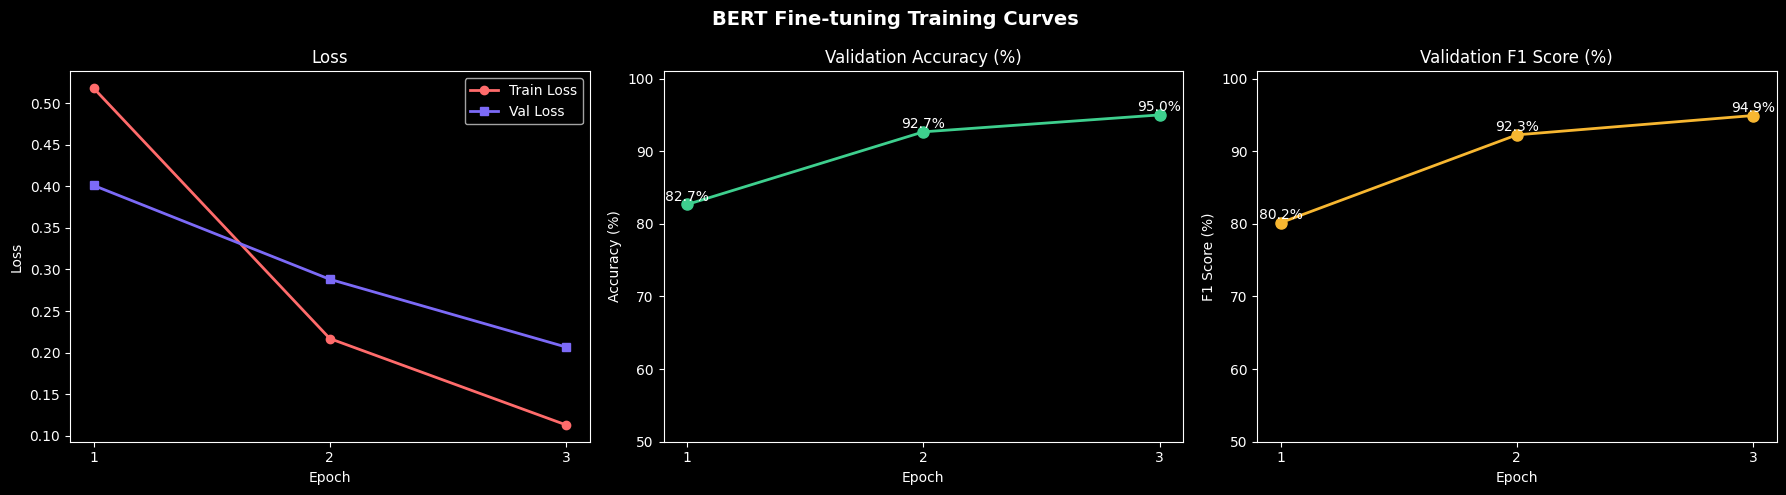

Training curves saved ✓


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BERT Fine-tuning Training Curves', fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#ff6b6b', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   's-', color='#7c6af7', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(epochs_range)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']], 'o-', color='#3ecf8e', linewidth=2, markersize=8)
axes[1].set_title('Validation Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(50, 101)
axes[1].set_xticks(epochs_range)
for i, v in enumerate(history['val_acc']):
    axes[1].annotate(f'{v*100:.1f}%', (i+1, v*100+0.5), ha='center', fontsize=10)

# F1
axes[2].plot(epochs_range, [f*100 for f in history['val_f1']], 'o-', color='#f7b731', linewidth=2, markersize=8)
axes[2].set_title('Validation F1 Score (%)', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score (%)')
axes[2].set_ylim(50, 101)
axes[2].set_xticks(epochs_range)
for i, v in enumerate(history['val_f1']):
    axes[2].annotate(f'{v*100:.1f}%', (i+1, v*100+0.5), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved ✓')

## 8. Final Evaluation on Test Set

In [33]:
# Load best model weights
model.load_state_dict(best_model_state)

# Evaluate on test set
test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, DEVICE
)
test_precision = precision_score(test_labels, test_preds)
test_recall    = recall_score(test_labels, test_preds)
test_auc       = roc_auc_score(test_labels, test_probs)

print('='*60)
print('BERT FINAL TEST SET RESULTS')
print('='*60)
print(f'Accuracy:  {test_acc*100:.2f}%')
print(f'F1 Score:  {test_f1*100:.2f}%')
print(f'Precision: {test_precision*100:.2f}%')
print(f'Recall:    {test_recall*100:.2f}%')
print(f'ROC-AUC:   {test_auc*100:.2f}%')
print('='*60)
print('\nDetailed Classification Report:')
print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))

BERT FINAL TEST SET RESULTS
Accuracy:  94.67%
F1 Score:  94.56%
Precision: 96.53%
Recall:    92.67%
ROC-AUC:   98.97%

Detailed Classification Report:
              precision    recall  f1-score   support

        REAL       0.93      0.97      0.95       150
        FAKE       0.97      0.93      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300




FULL MODEL COMPARISON:
              Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
            XGBoost     97.16     97.26      96.39   98.15    99.62
Logistic Regression     96.29     96.39      96.32   96.46    99.36
         DistilBERT     94.67     94.56      96.53   92.67    98.97
      Random Forest     93.29     93.56      92.27   94.88    98.23


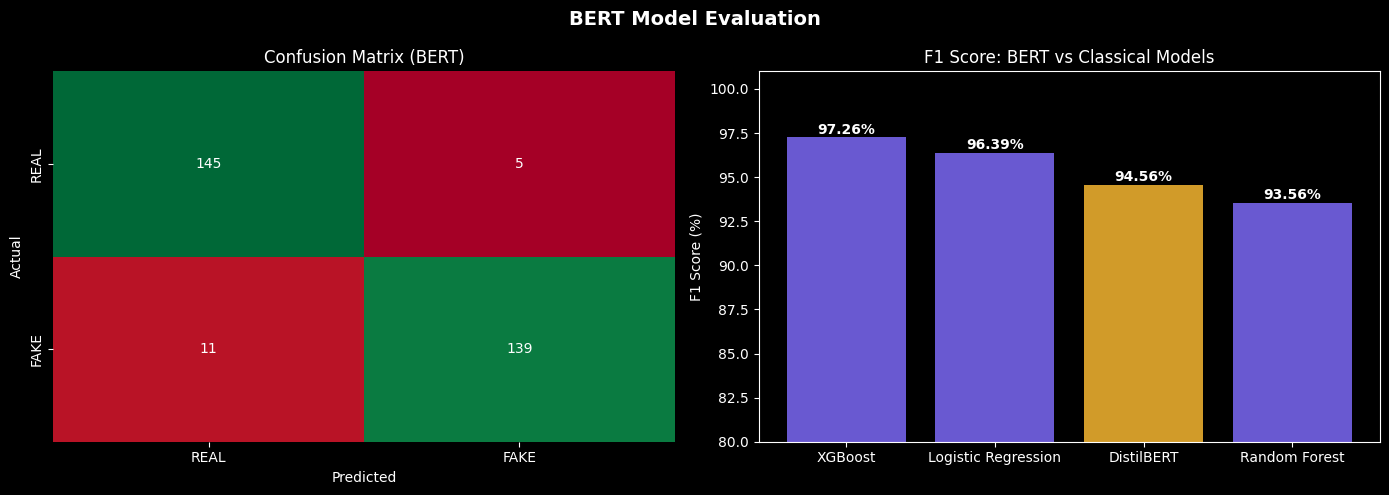

In [34]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Model Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'],
            ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (BERT)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Compare BERT vs classical models
results_path = f'{MODELS_DIR}model_results.json'
if os.path.exists(results_path):
    with open(results_path) as f:
        classic_results = json.load(f)

    bert_result = {
        'Model': 'DistilBERT',
        'Accuracy':  round(test_acc * 100, 2),
        'F1 Score':  round(test_f1 * 100, 2),
        'Precision': round(test_precision * 100, 2),
        'Recall':    round(test_recall * 100, 2),
        'ROC-AUC':   round(test_auc * 100, 2),
    }
    all_results = classic_results + [bert_result]
    all_df = pd.DataFrame(all_results).sort_values('F1 Score', ascending=False)

    # Bar chart comparison
    models_names = all_df['Model'].values
    f1_scores    = all_df['F1 Score'].values
    colors = ['#f7b731' if m == 'DistilBERT' else '#7c6af7' for m in models_names]
    bars = axes[1].bar(models_names, f1_scores, color=colors, alpha=0.85)
    axes[1].set_ylim(80, 101)
    axes[1].set_title('F1 Score: BERT vs Classical Models', fontsize=12)
    axes[1].set_ylabel('F1 Score (%)')
    for bar, val in zip(bars, f1_scores):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                     f'{val}%', ha='center', fontsize=10, fontweight='bold')

    print('\nFULL MODEL COMPARISON:')
    print(all_df.to_string(index=False))

    # Save updated results
    with open(results_path, 'w') as f:
        json.dump(all_results, f, indent=2)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}bert_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save BERT Model

In [35]:
# Save model and tokenizer in HuggingFace format
model.save_pretrained(BERT_DIR)
tokenizer.save_pretrained(BERT_DIR)
print(f'BERT model saved → {BERT_DIR}')

# Save results summary
bert_summary = {
    'model_name': MODEL_NAME,
    'epochs': EPOCHS,
    'sample_size': SAMPLE_SIZE,
    'max_length': MAX_LENGTH,
    'device': str(DEVICE),
    'test_accuracy': round(test_acc * 100, 2),
    'test_f1': round(test_f1 * 100, 2),
    'test_auc': round(test_auc * 100, 2),
    'training_history': history
}
with open(f'{MODELS_DIR}bert_summary.json', 'w') as f:
    json.dump(bert_summary, f, indent=2)
print('Training summary saved ✓')

print('\n' + '='*60)
print('NOTEBOOK 04 COMPLETE')
print('='*60)
print(f'DistilBERT fine-tuned successfully!')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test F1 Score: {test_f1*100:.2f}%')
print(f'Test ROC-AUC:  {test_auc*100:.2f}%')
print(f'\nModel saved to: {BERT_DIR}')
print('\nFiles in models/:')
for fname in sorted(os.listdir(MODELS_DIR)):
    path = f'{MODELS_DIR}{fname}'
    if os.path.isfile(path):
        size = os.path.getsize(path)
        print(f'  {fname}  ({size/1024:.1f} KB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved → ../models/bert_model/
Training summary saved ✓

NOTEBOOK 04 COMPLETE
DistilBERT fine-tuned successfully!
Test Accuracy: 94.67%
Test F1 Score: 94.56%
Test ROC-AUC:  98.97%

Model saved to: ../models/bert_model/

Files in models/:
  bert_evaluation.png  (64.3 KB)
  bert_summary.json  (0.6 KB)
  bert_training_curves.png  (107.2 KB)
  best_model.pkl  (776.5 KB)
  dbscan_results.png  (41.7 KB)
  eda_overview.png  (89.1 KB)
  kmeans_elbow.png  (92.7 KB)
  kmeans_model.pkl  (15748.3 KB)
  lda_model.pkl  (1844.8 KB)
  lda_topics.png  (33.9 KB)
  logistic_regression.pkl  (391.3 KB)
  model_comparison.png  (126.7 KB)
  model_results.json  (0.6 KB)
  random_forest.pkl  (34799.1 KB)
  tfidf_vectorizer.pkl  (1945.5 KB)
  top_words.png  (74.1 KB)
  topic_words.json  (1.2 KB)
  tsne_results.json  (134.5 KB)
  tsne_visualization.png  (826.5 KB)
  xgboost.pkl  (776.5 KB)


## 10. Test BERT on Sample Articles

In [36]:
def predict_bert(text, model, tokenizer, device, max_length=256):
    """Predict fake/real for a single article using BERT."""
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[0]
        pred    = outputs.logits.argmax(dim=1).item()

    return {
        'label':      'FAKE' if pred == 1 else 'REAL',
        'fake_prob':  round(probs[1].item(), 4),
        'real_prob':  round(probs[0].item(), 4),
        'confidence': round(max(probs).item(), 4)
    }

# Load best model
model.load_state_dict(best_model_state)

test_articles = [
    {
        'text': 'President Joe Biden signed the Inflation Reduction Act into law on Tuesday, marking the largest climate investment in United States history. The legislation allocates approximately 369 billion dollars toward clean energy programs.',
        'expected': 'REAL'
    },
    {
        'text': 'SHOCKING: Government secretly adding mind control chemicals to tap water! Whistleblower EXPOSES massive cover-up that mainstream media refuses to report. Share before it gets BANNED!!!',
        'expected': 'FAKE'
    },
    {
        'text': 'The United Nations Security Council held an emergency session to discuss escalating tensions. Secretary-General Antonio Guterres urged all parties to exercise maximum restraint and return to diplomatic negotiations.',
        'expected': 'REAL'
    },
    {
        'text': 'Scientists at NASA have confirmed the discovery of liquid water beneath the surface of Mars using radar data from the Mars Express orbiter. The findings were published in the journal Science.',
        'expected': 'REAL'
    }
]

print('BERT Predictions on Sample Articles:')
print('='*70)
for i, article in enumerate(test_articles):
    result = predict_bert(article['text'], model, tokenizer, DEVICE)
    status = '✓ CORRECT' if result['label'] == article['expected'] else '✗ WRONG'
    print(f'\nArticle {i+1}: {status}')
    print(f'  Text:       {article["text"][:80]}...')
    print(f'  Expected:   {article["expected"]}')
    print(f'  Predicted:  {result["label"]} (confidence: {result["confidence"]*100:.1f}%)')
    print(f'  Fake prob:  {result["fake_prob"]*100:.1f}%  |  Real prob: {result["real_prob"]*100:.1f}%')
print('='*70)

BERT Predictions on Sample Articles:

Article 1: ✓ CORRECT
  Text:       President Joe Biden signed the Inflation Reduction Act into law on Tuesday, mark...
  Expected:   REAL
  Predicted:  REAL (confidence: 96.9%)
  Fake prob:  3.1%  |  Real prob: 96.9%

Article 2: ✓ CORRECT
  Text:       SHOCKING: Government secretly adding mind control chemicals to tap water! Whistl...
  Expected:   FAKE
  Predicted:  FAKE (confidence: 91.8%)
  Fake prob:  91.8%  |  Real prob: 8.2%

Article 3: ✓ CORRECT
  Text:       The United Nations Security Council held an emergency session to discuss escalat...
  Expected:   REAL
  Predicted:  REAL (confidence: 97.7%)
  Fake prob:  2.3%  |  Real prob: 97.7%

Article 4: ✓ CORRECT
  Text:       Scientists at NASA have confirmed the discovery of liquid water beneath the surf...
  Expected:   REAL
  Predicted:  REAL (confidence: 61.7%)
  Fake prob:  38.3%  |  Real prob: 61.7%
